In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
import os
import time
import seaborn as sns
from sklearn.metrics import confusion_matrix
from torchsummary import summary
import torch.nn.utils.prune as prune

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # 습관처럼 무조건
print(device)

print(torch.__version__)

cuda
2.11.0+cu128


In [4]:
class SimpleDNN(nn.Module):
    def __init__(self):
        super(SimpleDNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

dnn_model = SimpleDNN()
print(dnn_model)


test_input = torch.randn(1, 1, 28, 28)
dnn_output = dnn_model(test_input)
print(dnn_output.shape)

SimpleDNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
torch.Size([1, 10])


In [6]:
sobel_filter = torch.tensor([[[[1.0, 0.0, -1.0],
                               [2.0, 0.0, -2.0],
                               [1.0, 0.0, -1.0]]]])

sample_28X28 = torch.randn(1, 1, 28, 28)
sobel_output = nn.functional.conv2d(sample_28X28, sobel_filter)
print(sobel_output.shape)

torch.Size([1, 1, 26, 26])


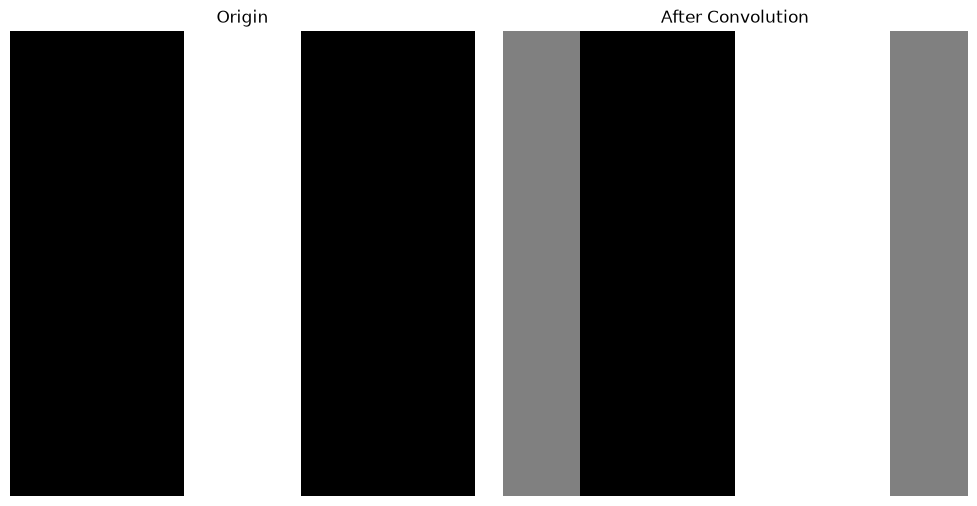

In [7]:
filter_2d = torch.tensor([[[1.0, 0.0, -1.0],
                           [1.0, 0.0, -1.0],
                           [1.0, 0.0, -1.0]]]).unsqueeze(0) # 3차원에서 unsqueeze 추가하면 4차원이되는것

sample_image_2 = torch.zeros(1, 1, 8, 8)
sample_image_2[0, 0, :, 3:5] = 1.0 # 이미지 중앙에 수직선을 그음

output_2 = nn.functional.conv2d(sample_image_2, filter_2d)

plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_image_2[0, 0].numpy(), cmap = "gray")
plt.title("Origin")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(output_2[0, 0].detach().numpy(), cmap = "gray")
plt.title("After Convolution")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
input_image = torch.randn(1, 1, 6, 6)
filter = torch.randn(1, 1, 3, 3)

# 출력 = {(입력 - 커널(filter) + 2 * 패딩) / stride} +1
output1 = F.conv2d(input_image, filter, stride = 1, padding = 0)
print(output1.shape)

output2 = F.conv2d(input_image, filter, stride = 1, padding = 1)
print(output2.shape)

output3 = F.conv2d(input_image, filter, stride = 2, padding = 0)
print(output3.shape)

torch.Size([1, 1, 4, 4])
torch.Size([1, 1, 6, 6])
torch.Size([1, 1, 2, 2])


In [11]:
input_rgb = torch.randn(1, 3, 32, 32)
filters = torch.randn(16, 3, 3, 3)

output4 = F.conv2d(input_rgb, filters, stride = 1, padding = 1)
print(output4.shape)

torch.Size([1, 16, 32, 32])


In [13]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3,
                               out_channels = 16,
                               kernel_size = 3,
                               stride = 1,
                               padding = 1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.conv2 = nn.Conv2d(in_channels = 16,
                               out_channels = 32,
                               kernel_size = 3,
                               stride = 1,
                               padding = 1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.fc = nn.Linear(2048, 10)

    def forward(self, x):
        # 첫번째 블록
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        # 두번째 블록
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        # 평탄화
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = SimpleCNN()
print(model)
sample_input = torch.randn(1, 3, 32, 32)
output = model(sample_input)
print(output.shape)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=2048, out_features=10, bias=True)
)
torch.Size([1, 10])


In [16]:
class CNNBatchNorm(nn.Module):
    def __init__(self):
        super(CNNBatchNorm, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3,
                               out_channels = 16,
                               kernel_size = 3,
                               stride = 1,
                               padding = 1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels = 16,
                               out_channels = 32,
                               kernel_size = 3,
                               stride = 1,
                               padding = 1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.fc = nn.Linear(2048, 10)

    def forward(self, x):
        # 첫번째 블록
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        # 두번째 블록
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        # 평탄화
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = CNNBatchNorm()
print(model)
sample_input = torch.randn(1, 3, 32, 32)
output = model(sample_input)
print(output.shape)

CNNBatchNorm(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=2048, out_features=10, bias=True)
)
torch.Size([1, 10])


In [18]:
class CNNDropout(nn.Module):
    def __init__(self):
        super(CNNDropout, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3,
                               out_channels = 16,
                               kernel_size = 3,
                               stride = 1,
                               padding = 1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.dropout1 = nn.Dropout(0.25)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels = 16,
                               out_channels = 32,
                               kernel_size = 3,
                               stride = 1,
                               padding = 1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.dropout2 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.dropout3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # 첫번째 블록
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        # 두번째 블록
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        # 평탄화
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.dropout3(x)
        x = self.fc2(x)
        return x

model = CNNDropout()
print(model)
# sample_input = torch.randn(1, 3, 32, 32)
# output = model(sample_input)
# print(output.shape)

CNNDropout(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (dropout3): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
transform_train = transforms.Compose([transforms.RandomCrop(32, padding = 4),
                                      transforms.RandomHorizontalFlip(), # 데이터 증강
                                      transforms.RandomRotation(15),
                                      transforms.ColorJitter(brightness = 0.2,
                                                             contrast = 0.2,
                                                             saturation = 0.2),
                                      transforms.ToTensor(),
                                      transforms.Normalize((0.4914, 0.4822, 0.4465),
                                                           (0.2470, 0.2435, 0.2616))])

transform_test = transforms.Compose([transforms.ToTensor(), # 데이터 증강 금지 절대안됨 증강하면 망하는거임
                                     transforms.Normalize((0.4914, 0.4822, 0.4465),
                                                          (0.2470, 0.2435, 0.2616))])

try:
    train_dataset = torchvision.datasets.CIFAR10(root = "./data",
                                                 train = True,
                                                 download = True,
                                                 transform = transform_train)
    test_dataset = torchvision.datasets.CIFAR10(root = "./data",
                                                train = False,
                                                download = True,
                                                transform = transform_test)

    train_loader = torch.utils.data.DataLoader(train_dataset,
                                               batch_size = 128,
                                               shuffle = True,
                                               num_workers = 0)
    test_loader = torch.utils.data.DataLoader(test_dataset,
                                              batch_size = 100,
                                              shuffle = False,
                                              num_workers = 0)
    print(len(train_dataset))
    print(len(test_dataset))
except Exception as e:
    print(f"오류발생 {e}")

100%|██████████| 170M/170M [47:45<00:00, 59.5kB/s]   


50000
10000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.5632443].


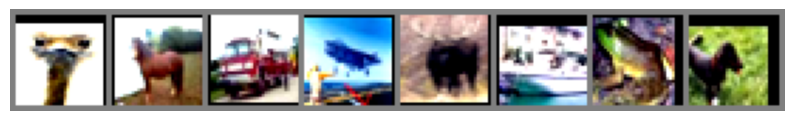

bird horse truck plane deer ship frog dog
torch.Size([3, 32, 32])
128
10


In [22]:
classes = ("plane",
           "car",
           "bird",
           "cat",
           "deer",
           "dog",
           "frog",
           "horse",
           "ship",
           "truck")

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.figure(figsize = (10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

try:
    dataiter = iter(train_loader)
    images, labels = next(dataiter)
    imshow(torchvision.utils.make_grid(images[:8]))
    print(" ".join(classes[labels[j]] for j in range(8)))
    print(images[0].shape)
    print(images.shape[0])
    print(len(classes))
except Exception as e:
    print(f"오류발생{e}")

In [23]:
# 이미지 다중 분류 모델

class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()
        self.features = nn.Sequential(nn.Conv2d(3, 32, kernel_size = 3, padding = 1),
                                      nn.BatchNorm2d(32),
                                      nn.ReLU(inplace = True),
                                      nn.Conv2d(32, 32, kernel_size = 3, padding = 1),
                                      nn.BatchNorm2d(32),
                                      nn.ReLU(inplace = True),
                                      nn.MaxPool2d(kernel_size = 2, stride = 2),
                                      nn.Dropout2d(0.25),
                                      nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
                                      nn.BatchNorm2d(64),
                                      nn.ReLU(inplace = True),
                                      nn.MaxPool2d(kernel_size = 2, stride = 2),
                                      nn.Dropout2d(0.25),
                                      nn.Conv2d(64, 128, kernel_size = 3, padding = 1),
                                      nn.BatchNorm2d(128),
                                      nn.ReLU(inplace = True),
                                      nn.Conv2d(128, 128, kernel_size = 3, padding = 1),
                                      nn.BatchNorm2d(128),
                                      nn.ReLU(inplace = True),
                                      nn.MaxPool2d(kernel_size = 2, stride = 2),
                                      nn.Dropout2d(0.25))

        self.classifier = nn.Sequential(nn.Flatten(),
                                        nn.Linear(128 * 4 * 4, 512),
                                        nn.ReLU(inplace = True),
                                        nn.Dropout(0.5),
                                        nn.Linear(512, 10))

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cifar_model = CIFAR10_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cifar_model.parameters(), lr = 0.001)
print(cifar_model)

cifar_params = sum(p.numel() for p in cifar_model.parameters())
print(cifar_params)
print(device)

CIFAR10_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout2d(p=0.25, inplace=False)
    (13): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): BatchNorm2d(128, eps=1e-05, momentum=0.1, af

In [25]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(train_loader):
        if i >= 10:
            break
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        if i % 5 == 4:
            print(f"배치: {i + 1}, 손실: {running_loss / (i + 1)}, 정확도: {100 * correct / total}")
    return running_loss / min(i + 1, 10), 100 * correct / total

def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad(): # 주요 포인트 model.eval()이후 반드시 필요
        for i, (inputs, labels) in enumerate(test_loader):
            if i >= 5:
                break
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return test_loss / (i + 1), 100 * correct / total

try:
    if "train_loader" in locals():
        for epoch in range(2):
            print(epoch + 1)
            train_loss, train_acc = train_epoch(cifar_model,
                                                train_loader,
                                                criterion,
                                                optimizer,
                                                device)
            test_loss, test_acc = evaluate_model(cifar_model,
                                                 test_loader,
                                                 criterion,
                                                 device)
            print(test_loss, test_acc)
    else:
        print("데이터 준비되지 않음")
except Exception as e:
    print(f"오류발생 {e}")

1
배치: 5, 손실: 2.57904691696167, 정확도: 11.09375
배치: 10, 손실: 2.453358459472656, 정확도: 12.890625
1.902169108390808 12.2
2
배치: 5, 손실: 2.1260889530181886, 정확도: 22.8125
배치: 10, 손실: 2.1480746507644652, 정확도: 22.34375
1.7440693378448486 18.6


In [ ]:
S